##1 Data description and Setup

See the original notebook: https://github.com/niekveldhuis/compass/blob/master/2_3_Data_Acquisition_CDLI/2_3_Data_Acquisition_CDLI.ipynb

The [Cuneiform Digital Library Initiative](https://cdli.mpiwg-berlin.mpg.de/), created by [Bob Englund](https://cdli.ucla.edu/?q=robert-k-englund) (UCLA) in the early two thousands, is a central repository for meta-data, images, and transliterations of cuneiform objects (translations are offered only for a small minority of texts). Today more than 335,000 objects are listed in the [CDLI](https://cdli.mpiwg-berlin.mpg.de/) catalog, with tens of thousands of photographs and line drawings. Each object in [CDLI](https://cdli.mpiwg-berlin.mpg.de/) receives a unique ID number (the so-called P-number), and these numbers are widely used today in print and in on-line projects. Initially, [CDLI](https://cdli.mpiwg-berlin.mpg.de/) focused primarily on administrative texts from the third millennium, and this is still the area of its greatest strength. Currently, approximately 121,000 texts are available in transliteration in [CDLI](https://cdli.mpiwg-berlin.mpg.de/). Part of this corpus was produced by the [CDLI](https://cdli.mpiwg-berlin.mpg.de/) team at UCLA, others were contributed by partners or were imported from other projects such as [ETCSL](https://etcsl.orinst.ox.ac.uk/) (for Sumerian literary texts), [DCCLT](http://oracc.org/dcclt) (for lexical texts), or [BDTNS](http://bdtns.filol.csic.es/) (for Ur III administrative texts). The photographs on [CDLI](https://cdli.mpiwg-berlin.mpg.de/) were largely produced in cooperative projects with museums all over the world, where [CDLI](https://cdli.mpiwg-berlin.mpg.de/) staff or partners would go to scan an entire collection or major parts of a collection. These images are copyright of the museum where the object is held and there is no wholesale downloading of the entire image set.

The [CDLI](https://cdli.mpiwg-berlin.mpg.de/) project transformed the practice of Assyriology in multiple ways. The availability of large numbers of photographs made it possible to collate problematic passages in texts only published in transliteration and/or hand drawing. Issuing ID numbers made it easier to refer to a particular tablet unambiguously, while avoiding the confusion of obscure publication abbreviations and museum numbers. The spread of all this information on the web made it available to everyone with an internet connection.

For each cuneiform object the [CDLI](https://cdli.mpiwg-berlin.mpg.de/) catalog provides information about where it was published (and by whom), in which collection it is kept, where it was excavated, to which period it belongs, what textual genre it represents, etc. In addition, an object may be represented by one or more images (photographs and/or hand drawings) and by a transliteration. Several of the fields in the [CDLI](https://cdli.mpiwg-berlin.mpg.de/) catalog either use a restricted vocabulary (period, genre) or have been standardized (provenance, author's name, owner, museum number), greatly facilitating search.

The issue of standardization is much more difficult for linguistic data in transliteration. Here, Sumerian and Akkadian pose rather different challenges. For Sumerian, there are two main issues. First, Sumerologists tend to use different sets of conventions for representing Sumerian words in the Latin alphabet. The word for "to give" is read [**šum₂**](http://oracc.org/epsd2/o0039914) by some, but **sum** by others. Similarly, the word for "ox" is read either [**gud**](http://oracc.org/epsd2/o0028670) or **gu₄**. These readings (**šum₂** vs **sum** or **gud** vs. **gu₄**) represent the same word and render the same cuneiform sign - they simply differ in modern transliteration conventions. Variation in such conventions has grown recently by the introduction of a new set of readings by P. Attinger (Bern), which has received wide following, in particular in Germany. Such variation in sign readings is based on the one hand on differing interpretations of the data from [ancient sign lists](http://oracc.org/dcclt/signlists) (which provide transcriptions of Sumerian words in Akkadian) and on the other hand on the definition of what an ideal transliteration should achieve (whether it should represent the abstract lexeme, or rather its concrete pronunciation, or something in between). For the [CDLI](https://cdli.mpiwg-berlin.mpg.de/) search engine, which is based on a FileMaker database, such variation presents a problem when searching for (Sumerian) words. The solution has been to strictly impose a set of [preferred sign readings](https://cdli.ucla.edu/methods/sign_reading.html), a policy that has been carried out with admirable consistency.

:::{admonition} Attinger readings
:class: tip, dropdown
For the readings introduced by P. Attinger, see the introduction to his [Glossaire sumérien–français](https://www.harrassowitz-verlag.de/isbn_9783447116169.ahtml) (2021).
:::

Second, Sumerologists today have no good standard for word segmentation. In the [CDLI](https://cdli.mpiwg-berlin.mpg.de/) data set one may find the word [**ninda-i₃-de₂-a**](http://oracc.org/epsd2/o0036259) (a pastry) transliterated as **ninda-i₃-de₂-a**, **ninda i₃-de₂-a**, **ninda i₃ de₂-a**, **nig₂-i₃-de₂-a**, **nig₂ i₃ de₂-a**, etcetera (**nig₂** and **ninda** are two different words, written by the same sign and there is no full agreement which of these is to be used in this particular expression). None of these various renderings is necessarily "wrong," because we know fairly little about the formation and segmentation of Sumerian nouns. For computational approaches this variation poses an important challenge.

For Akkadian the variation in reading conventions plays a much smaller role; for most dialects of Akkadian (with the exception of Old Akkadian) scholars generally agree on transliteration conventions; word segmentation is hardly ever a problem. For search engines, however, Akkadian transliteration is much more difficult to deal with because the same word may be spelled in many different ways. Without lemmatization, there is no way a machine can tell that ***ša-ar-ru-um***, ***ša-ar-ri-im***, ***ša-ar-ra-am***, ***šar-ru***, ***šar-ri***, ***šar-ra***, **LUGAL**, and **MAN** all represent forms of the same word for "king" in syllabic and logographic writing. The rich morphology of Akkadian, with prefixes, suffixes, and infixes and various vowel patterns to be applied to different forms of a single verb further complicates this issue.

Since [CDLI](https://cdli.mpiwg-berlin.mpg.de/) does not offer lemmatization, searching for words on this site is much more popular (and more useful) for Sumerian than it is for Akkadian. Sumerian words usually include the root of the word (written logographically) with prefixes and/or suffixes attached. Although spelling variations exist (e.g. **dag-si**, **da-ag-si**, **da-ag-ši-um**, and **da-ag-zi-um**, all representing variants of the word [dagsi](http://oracc.org/epsd2/o0025593) for saddle hook or saddle bag), such variation plays a much smaller role in Sumerian than in Akkadian.

*`italicized text`*## Mount the notebook in Colab

In [ ]:
import requests
from tqdm.auto import tqdm
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt

##2 Sign Lists Crosslist Dictionary

###2.1 Sign lists prepping


#### 2.1.1 Nuolenna Sign List



In [ ]:
# Reading in the signlist from json format
Nuolenna = pd.read_json('https://raw.githubusercontent.com/situx/Nuolenna/master/sign_list.json', orient='index')

In [ ]:
#Qid sign matching signlist:
WDqid_signlist = pd.read_csv('https://raw.githubusercontent.com/HarrisonLiruiHuang/WDqid_signlist/refs/heads/main/WDqid_signlabel_oslid.csv')
WDqid_signlist = WDqid_signlist[['Actual','oslid']]
WDqid_signlist

def flatten_and_deduplicate(values):
    flat_list = [item for sublist in values for item in (sublist if isinstance(sublist, list) else [sublist])]
    return list(set(flat_list))

In [ ]:
# name the columns, cleaning, rearranging
Nuolenna.columns = ['unicode']
form = Nuolenna.index.tolist()
Nuolenna['sign'] = form
desired_order = ['sign', 'unicode']
Nuolenna = Nuolenna[desired_order]
Nuolenna = Nuolenna.reset_index(drop=True)
Nuolenna

,sign,unicode
0,(4×za)×kur,𒍟
1,(an.naga)@(an.naga),𒀰
2,(bu&bu)×na₂,𒒈
3,(kaskal.lagab×u)&(kaskal.lagab×u),𒆞
4,(muš&muš)×ga,𒔤
...,...,...
12612,ṭu₃,𒁺
12613,ṭu₄,𒌈
12614,ṭu₅,𒃮
12615,ṭu₆,𒅲


#### 2.1.2 Akkadamia Sign List

Akkademia Sign List (concat signlist)
Check against this sign list: https://github.com/gaigutherz/Akkademia/blob/master/cuneiform_to_unicode_fixed.csv

(The format shoudl be the same...)

* Evaluate & Check with Akkademia Sign List:
* compare Nuolenna sign_list.json against the Akkademia sign list
* create a new dataframe with all the signs and values in CSV format



In [ ]:
akkademia = pd.read_csv('https://raw.githubusercontent.com/gaigutherz/Akkademia/master/cuneiform_to_unicode_fixed.csv')
akkademia

,sign,unicode
0,ʾu₄,𒀀
1,'u4,𒀀
2,a,𒀀
3,aia₂,𒀀
4,aia2,𒀀
...,...,...
14236,/,𒑰
14237,:,𒑱
14238,":""",𒑲
14239,:.,𒑳


In [ ]:
concatenated = pd.merge(Nuolenna, akkademia, on=['sign', 'unicode'], how='outer', indicator=True)
concatenated['_merge'] = concatenated['_merge'].replace({'left_only': 'sign_list', 'right_only': 'akkademia'})
non_overlapping_rows = concatenated[concatenated['_merge'] != 'both']

/tmp/ipython-input-2802032317.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  concatenated['_merge'] = concatenated['_merge'].replace({'left_only': 'sign_list', 'right_only': 'akkademia'})


In [ ]:
concatenated

,sign,unicode,_merge
0,',𒀪,akkademia
1,'a,𒀪,akkademia
2,'a3,𒂍,akkademia
3,'a4,𒄩,akkademia
4,'a5,𒉌,akkademia
...,...,...,...
18192,ṭu₄,𒌈,both
18193,ṭu₅,𒃮,both
18194,ṭu₆,𒅲,both
18195,ṭēmu,𒅗𒄭,both


In [ ]:
non_overlapping_rows.columns = ["cdli_sign","cdli_unicode",'merge']
non_overlapping_rows

,cdli_sign,cdli_unicode,merge
0,',𒀪,akkademia
1,'a,𒀪,akkademia
2,'a3,𒂍,akkademia
3,'a4,𒄩,akkademia
4,'a5,𒉌,akkademia
...,...,...,...
18053,šu₂.naga,𒋙𒉀,sign_list
18054,šu₂.ne,𒋙𒉈,sign_list
18055,šu₂.u.u.u,𒋙𒌋𒌋𒌋,sign_list
18056,šu₂.ur@s,𒋙𒌪,sign_list


#### 2.1.3 Cuneiml, Text_fabric signlist

In [ ]:
#Signlist_prepping
#Pipeline analyzing unique sign, unicodes for CuneiML,Cdli2cun,Nuolenna,TextFabric:
#Read in df
cuneiml_signlist = pd.read_csv(
    'https://raw.githubusercontent.com/taineleau/CuneiML/main/cuneiform_unicode/cuneiform_vocab.txt',
    sep='\t'
)
Text_fabric_sign_list = pd.read_json('https://raw.githubusercontent.com/Nino-cunei/oldbabylonian/refs/heads/master/sources/writing/GeneratedSignList.json')
Text_fabric_sign_list_normal = pd.json_normalize(Text_fabric_sign_list['signs'])

final_Text_fabric_sign_list_normal = Text_fabric_sign_list_normal[['signCunei','values']].explode('values')



#   [['signName','signCunei']]

# #Formatting the cuneiml
cuneiml_signlist.loc[-1] = cuneiml_signlist.columns  # Adding a row with column names
cuneiml_signlist.index = cuneiml_signlist.index + 1  # Shifting the index
cuneiml_signlist = cuneiml_signlist.sort_index()  # Sorting by index to have the new row at the top

cuneiml_signlist.columns = ["cuneiml_sign","cuneiml_unicode"]

In [ ]:
final_Text_fabric_sign_list_normal

,signCunei,values
0,𒀸,AŠ
0,𒀸,1
0,𒀸,ANA3
0,𒀸,AS3
0,𒀸,AṢ3
...,...,...
1764,𒋟,ŠIKAḪARA
1765,𒇱,LAḪŠU
1765,𒇱,ḪIxPA.NUN.U?
1766,𒆶,KWU318


In [ ]:
cuneiml_signlist

,cuneiml_sign,cuneiml_unicode
0,kil,𒆸
1,kim,𒁶
2,kin,𒆥
3,dib2,𒆪
4,kid,𒆤
...,...,...
7232,tir,𒌁
7233,_{lu2}hun,𒇽 𒂠
7234,178,𒐖 𒐐 𒐍
7235,mašgi;,𒌐


In [ ]:
Text_fabric_sign_list

,signs
AŠ,"{'signName': 'AŠ', 'signNumber': 1, 'signCunei..."
AŠ.DAR,"{'signName': 'AŠ.DAR', 'signNumber': -1, 'sign..."
AŠ.A.AN,"{'signName': 'AŠ.A.AN', 'signNumber': -1, 'sig..."
AŠ.AŠ,"{'signName': 'AŠ.AŠ', 'signNumber': 2, 'signCu..."
ḪAL,"{'signName': 'ḪAL', 'signNumber': 3, 'signCune..."
...,...
MURGU,"{'signName': 'MURGU', 'signNumber': 906, 'sign..."
SIG4overSIG4.ŠU2,"{'signName': 'SIG4overSIG4.ŠU2', 'signNumber':..."
LAḪŠU,"{'signName': 'LAḪŠU', 'signNumber': 0, 'signCu..."
KWU318,"{'signName': 'KWU318', 'signNumber': 0, 'signC..."


###2.2 Cross list sign matching & qid matching

#### 2.2.1 Using OSL as a starting column for matching

In [ ]:
'''
@oid
@sign
@list
@ucun
@v
@link	eBL
'''
# # Specify the file URL
# file_url = "https://raw.githubusercontent.com/oracc/osl/master/00lib/osl.asl"

# # Fetch the file content from the URL
# response = requests.get(file_url)
# if response.status_code != 200:
#     raise Exception(f"Failed to fetch file. Status code: {response.status_code}")
# file_content = response.text

# # Initialize list to store each structured entry as a dictionary
# extracted_data = []
# current_entry = {}

# # Process the file line by line
# for line in file_content.splitlines():
#     # Check if line starts with '@oid' and start a new entry
#     if line.startswith("@oid") and "\t" in line:
#         oid_value = line.split("\t")[1].strip()
#         # Add new oid to the next available oid column
#         oid_count = sum(1 for key in current_entry if key.startswith("oid"))
#         current_entry[f"oid_{oid_count + 1}"] = oid_value
#     elif line.startswith("@sign"):
#         current_entry = {"sign": line.split()[1].strip()}
#     elif line.startswith("@list ") and "\t" in line:
#         current_entry["list"] = line.split("\t")[1].strip()
#     elif line.startswith("@ucun") and "\t" in line:
#         current_entry["ucun"] = line.split("\t")[1].strip()
#     elif line.startswith("@v") and "\t" in line:
#         if "v" not in current_entry:
#             current_entry["v"] = []
#         current_entry["v"].append(line.split("\t")[1].strip())
#     elif line.startswith("@link	eBL") and "\t" in line:
#         current_entry["link	eBL"] = line.split("\t")[1].strip()
#     elif line.startswith("@end sign"):
#         # Append the current entry to the list and reset for the next entry
#         extracted_data.append(current_entry)
#         current_entry = {}

# # Convert the list of dictionaries to a DataFrame
# Osl_df = pd.DataFrame(extracted_data).rename(columns={'sign': 'OSL(form)', 'ucun': 'OSL(sign)'}).iloc[:, list(range(5)) + [-1]]

# # Display the first 30 rows
# Osl_df.head(30)

'\n@oid\n@sign\n@list\n@ucun\n@v\n@link\teBL\n'

In [ ]:
import requests
import pandas as pd

'''
@oid
@sign
@list
@ucun
@v
@link	eBL
'''

# Specify the file URL
file_url = "https://raw.githubusercontent.com/oracc/osl/master/00lib/osl.asl"

# Fetch the file content from the URL
response = requests.get(file_url)
response.raise_for_status()
file_content = response.text

# Collect final rows: one row per (FORM=|...|, SIGN=cuneiform @ucun, VALUE=@v)
rows = []
current = {}
current_ucun = None         # current cuneiform in effect
variant_index = -1          # 0 for first (canonical), 1+ for variants
emitted_since_ucun = False  # did we emit any @v for the current_ucun?

for line in file_content.splitlines():
    if line.startswith("@oid") and "\t" in line:
        oid = line.split("\t", 1)[1].strip()
        # assign to next available oid_n
        n = 1
        while f"oid_{n}" in current:
            n += 1
        current[f"oid_{n}"] = oid

    elif line.startswith("@sign"):
        # start a new sign block (FORM)
        current = {"sign": line.split()[1].strip()}
        current_ucun = None
        variant_index = -1
        emitted_since_ucun = False

    elif line.startswith("@list ") and "\t" in line:
        current["list"] = line.split("\t", 1)[1].strip()

    elif line.startswith("@ucun") and "\t" in line:
        # if previous ucun had no values, emit a None row for it (to preserve the variant)
        if current_ucun is not None and not emitted_since_ucun:
            base = {k: v for k, v in current.items() if not isinstance(v, (list, dict))}
            base.update({"ucun": current_ucun, "value": None, "variant_index": variant_index})
            rows.append(base)

        current_ucun = line.split("\t", 1)[1].strip()
        variant_index += 1
        emitted_since_ucun = False

    elif line.startswith("@v") and "\t" in line:
        # emit one row per value, paired with the closest preceding ucun
        val = line.split("\t", 1)[1].strip()
        base = {k: v for k, v in current.items() if not isinstance(v, (list, dict))}
        base.update({"ucun": current_ucun, "value": val, "variant_index": variant_index})
        rows.append(base)
        emitted_since_ucun = True

    elif line.startswith("@link\teBL") and "\t" in line:
        current["link_eBL"] = line.split("\t", 1)[1].strip()

    elif line.startswith("@end sign"):
        # if the last ucun in this block had no values, preserve it with a None value
        if current_ucun is not None and not emitted_since_ucun:
            base = {k: v for k, v in current.items() if not isinstance(v, (list, dict))}
            base.update({"ucun": current_ucun, "value": None, "variant_index": variant_index})
            rows.append(base)
        # reset for next block
        current = {}
        current_ucun = None
        variant_index = -1
        emitted_since_ucun = False

# Build DataFrame with your labels
Osl_df = (
    pd.DataFrame(rows)
      .rename(columns={
          'sign':  'OSL(form)',   # your FORM label like |A.EDIN.LAL|
          'ucun':  'OSL(sign)',   # cuneiform string
          'value': 'OSL(value)'   # the paired @v
      })
)

# Keep your original column ordering style
preferred_cols = [
    "oid_1","oid_2","oid_3",
    "OSL(form)","list",
    "OSL(sign)","OSL(value)",
    "link_eBL","variant_index"
]
Osl_df = Osl_df[[c for c in preferred_cols if c in Osl_df.columns]]

# Show the first 30 rows
Osl_df


,oid_1,oid_2,oid_3,OSL(form),OSL(sign),OSL(value),link_eBL,variant_index
0,o0000087,NaN,NaN,A,𒀀,ʾu₄,NaN,0
1,o0000087,NaN,NaN,A,𒀀,a,NaN,0
2,o0000087,NaN,NaN,A,𒀀,aia₂,NaN,0
3,o0000087,NaN,NaN,A,𒀀,aya₂,NaN,0
4,o0000087,NaN,NaN,A,𒀀,barₓ,NaN,0
...,...,...,...,...,...,...,...,...
12274,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(ŋešʾu@v),NaN,0
12275,o0027234,NaN,NaN,NaN,None,1(aš@f),NaN,-1
12276,o0027234,o0027294,o0027327,NaN,None,2(u@f),NaN,-1
12277,o0027234,o0027294,o0027327,NaN,None,3(u@f),NaN,-1


In [ ]:
Osl_df.to_csv('Osl_df.csv', index=False)


In [ ]:
wiki_df = pd.read_csv('https://raw.githubusercontent.com/HarrisonLiruiHuang/WDqid_signlist/refs/heads/main/wikidata.csv')

In [ ]:
wiki_df

,cuneichar,cuneicharAltLabel,cuneicharLabel,phoneticValues,oslIDs
0,http://www.wikidata.org/entity/Q87556488,"CUNEIFORM SIGN TAG TIMES SHE, U+122F6",𒋶,tibirₓ,o0002400
1,http://www.wikidata.org/entity/Q87555968,"CUNEIFORM SIGN LAGAB TIMES TAK4, U+121E3",𒇣,"šurun₂, šara₃, bara₈, ninmuš, para₈, šuru₂",o0001834
2,http://www.wikidata.org/entity/Q87555978,"sul, CUNEIFORM SIGN LAGAB TIMES U2 PLUS ASH, U...",𒇨,"ugra, ušera, ugri, ušeri",o0001789
3,http://www.wikidata.org/entity/Q87556506,"CUNEIFORM SIGN TIR OVER TIR, U+12303",𒌃,"garadin₆, karadin₆, nenni₅, ninni₅",o0000639
4,http://www.wikidata.org/entity/Q87556508,CUNEIFORM SIGN TIR OVER TIR GAD OVER GAD GAR O...,𒌄,"garadin, karadin",o0000635
...,...,...,...,...,...
1211,http://www.wikidata.org/entity/Q87555885,"CUNEIFORM SIGN LAGAB TIMES A PLUS DA PLUS HA, ...",𒆺,edakua₂,o0001775
1212,http://www.wikidata.org/entity/Q87557458,"CUNEIFORM SIGN SHU2 PLUS E2 TIMES AN, U+12537",𒔷,NaN,o0002807
1213,http://www.wikidata.org/entity/Q22908417,"Ša, CUNEIFORM SIGN SHA, U+122AD",𒊭,"ara, ša, en₈, li₅, na₅, sa₂₀, zur₈",o0002824
1214,http://www.wikidata.org/entity/Q87557463,"CUNEIFORM SIGN TUM TIMES GAN2 TENU, U+1253A",𒔺,NaN,o0002429


In [ ]:
# Step 1: Make sure the column is string (to handle NaN safely)
wiki_df['phoneticValues'] = wiki_df['phoneticValues'].astype(str)

# Step 2: Split on comma and strip spaces
wiki_df['phoneticValues'] = wiki_df['phoneticValues'].str.split(',')

# Step 3: Remove extra whitespace from each value
wiki_df['phoneticValues'] = wiki_df['phoneticValues'].apply(lambda lst: [x.strip() for x in lst])

# Step 4: Explode
wiki_df = wiki_df.explode('phoneticValues').reset_index(drop=True)

wiki_df

,cuneichar,cuneicharAltLabel,cuneicharLabel,phoneticValues,oslIDs
0,http://www.wikidata.org/entity/Q87556488,"CUNEIFORM SIGN TAG TIMES SHE, U+122F6",𒋶,tibirₓ,o0002400
1,http://www.wikidata.org/entity/Q87555968,"CUNEIFORM SIGN LAGAB TIMES TAK4, U+121E3",𒇣,šurun₂,o0001834
2,http://www.wikidata.org/entity/Q87555968,"CUNEIFORM SIGN LAGAB TIMES TAK4, U+121E3",𒇣,šara₃,o0001834
3,http://www.wikidata.org/entity/Q87555968,"CUNEIFORM SIGN LAGAB TIMES TAK4, U+121E3",𒇣,bara₈,o0001834
4,http://www.wikidata.org/entity/Q87555968,"CUNEIFORM SIGN LAGAB TIMES TAK4, U+121E3",𒇣,ninmuš,o0001834
...,...,...,...,...,...
6792,http://www.wikidata.org/entity/Q87556356,"CUNEIFORM SIGN SHA3, U+122AE",𒊮,lip₃,o0002828
6793,http://www.wikidata.org/entity/Q87556356,"CUNEIFORM SIGN SHA3, U+122AE",𒊮,pešₓ,o0002828
6794,http://www.wikidata.org/entity/Q87556356,"CUNEIFORM SIGN SHA3, U+122AE",𒊮,sa₁₉,o0002828
6795,http://www.wikidata.org/entity/Q87556356,"CUNEIFORM SIGN SHA3, U+122AE",𒊮,šab₂,o0002828


In [ ]:
#Match other df to osl df
# TextFabric = final_Text_fabric_sign_list_normal
# Nuolenna = Nuolenna
# CuneiML = cuneiml_signlist
# Akkademia = akkademia
# CDLI = non_overlapping_rows
# SumTablets
# eBL (link)

CDLI_df = non_overlapping_rows
TextFabric_df = final_Text_fabric_sign_list_normal
Cuneiml_df = cuneiml_signlist
Akkademia_df = akkademia
Nuolenna_df = Nuolenna

In [ ]:
Akkademia_df = Akkademia_df.rename(columns={"sign": "akkademia_sign", "unicode": "akkademia_unicode"})
TextFabric_df = TextFabric_df.rename(columns={"values": "textfabric_value", "signCunei": "textfabric_sign"})
wiki_df = wiki_df[["cuneicharLabel","phoneticValues","oslIDs"]].rename(columns={"cuneicharLabel": "wiki_sign", "phoneticValues": "wiki_value"})
Cuneiml_df.columns = ["cuneiml_value", "cuneiml_sign"]
CDLI_df.columns = ["cdli_value", "cdli_sign",'merge_status']
Akkademia_df.columns = ["akkademia_value", "akkademia_sign"]
Nuolenna_df.columns = ["nuolenna_value", "nuolenna_sign"]

In [ ]:
TextFabric_df

,textfabric_sign,textfabric_value
0,𒀸,AŠ
0,𒀸,1
0,𒀸,ANA3
0,𒀸,AS3
0,𒀸,AṢ3
...,...,...
1764,𒋟,ŠIKAḪARA
1765,𒇱,LAḪŠU
1765,𒇱,ḪIxPA.NUN.U?
1766,𒆶,KWU318


In [ ]:
# import pandas as pd
# import re
# import match_counts

# def normalize_subscripts(value):
#     subscript_map = str.maketrans('₀₁₂₃₄₅₆₇₈₉', '0123456789')
#     value = re.sub(r'[₀₁₂₃₄₅₆₇₈₉]', lambda x: x.group(0).translate(subscript_map), value)
#     value = value.replace('ʾ', "'").replace('?', '')
#     return value

# # --- Normalize and Clean Osl_df ---
# Osl_df = Osl_df.explode('v').reset_index(drop=True)
# Osl_df = Osl_df[Osl_df['v'].notna()]
# Osl_df['Normalized_v'] = Osl_df['v'].apply(normalize_subscripts)

# # --- Merge Info: [(right_df, left_on, right_on)] ---
# merge_info = [
#     (Cuneiml_df, 'Normalized_v', 'cuneiml_value'),
#     (CDLI_df, 'Normalized_v', 'cdli_value'),
#     (TextFabric_df, 'Normalized_v', 'textfabric_value'),
#     (Akkademia_df, 'Normalized_v', 'akkademia_value'),
#     (Nuolenna_df, 'Normalized_v', 'nuolenna_value'),
#     (wiki_df, 'Normalized_v', 'wiki_value')
# ]

# # --- Perform Merges Dynamically ---
# new_osl = Osl_df.copy()

# for right_df, left_on, right_on in merge_info:
#     pre_cols = list(new_osl.columns)
#     new_osl = pd.merge(new_osl, right_df, left_on=left_on, right_on=right_on, how='left')

#     # Optional: Select only new columns added from the merge
#     new_cols = [col for col in new_osl.columns if col not in pre_cols]
#     print(f"Merged with {right_on}, added columns: {new_cols}")

# # --- Compare Unicode Columns to OSL ---
# unicode_columns = ["textfabric_sign", "nuolenna_sign", "akkademia_sign", "cdli_sign", "cuneiml_sign","wiki_sign"]
# for col in unicode_columns:
#     match = new_osl['OSL(sign)'] == new_osl[col]
#     new_osl[f'{col}_match'] = match
#     print(f"{col}: {match.sum()} matches ({match.sum() / len(match) * 100:.2f}%)")

# # --- Optional: Print sizes of source DataFrames ---
# df_names = {
#     "TextFabric_df": TextFabric_df,
#     "Nuolenna_df": Nuolenna_df,
#     "Akkademia_df": Akkademia_df,
#     "CDLI_df": CDLI_df,
#     "Cuneiml_df": Cuneiml_df,
#     "wiki_df": wiki_df
# }
# for name, df in df_names.items():
#     print(f"{name}: {len(df)} rows")

# # --- Check non-null counts for sign matches ---
# match_columns = ["textfabric_sign", "nuolenna_sign", "akkademia_sign", "cdli_sign", "cuneiml_sign", "wiki_sign"]
# for sign in match_columns:
#     print(f"{sign}: {new_osl[sign].notna().sum()} non-empty values")


# # --- Compute Match Percentages ---
# match_percentages = {col: (count / total_rows) * 100 for col, count in match_counts.items()}

# # --- Plotting ---
# plt.figure(figsize=(10, 6))
# bars = plt.bar(match_percentages.keys(), match_percentages.values(), color='skyblue')

# # Add percentage labels above bars
# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# # Formatting
# plt.title('Match Percentage of Sign Columns vs OSL(sign)', fontsize=14)
# plt.xlabel('Sign Source', fontsize=12)
# plt.ylabel('Match %', fontsize=12)
# plt.ylim(0, 110)
# plt.xticks(rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()

# # Show plot
# plt.show()

# import matplotlib.pyplot as plt

# # --- Columns you're comparing ---
# unicode_columns = ["textfabric_sign", "nuolenna_sign", "akkademia_sign", "cdli_sign", "cuneiml_sign", "wiki_sign"]
# total_rows = len(new_osl)

# # --- Count non-empty entries ---
# non_empty_counts = {col: new_osl[col].notna().sum() for col in unicode_columns}
# non_empty_percentages = {col: (count / total_rows) * 100 for col, count in non_empty_counts.items()}

# # --- Plot: Non-Empty Value Percentage ---
# plt.figure(figsize=(10, 6))
# bars = plt.bar(non_empty_percentages.keys(), non_empty_percentages.values(), color='orange')

# # Add labels above bars
# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# plt.title('Non-Empty Sign Value Percentage by Source', fontsize=14)
# plt.xlabel('Sign Source', fontsize=12)
# plt.ylabel('Non-Empty %', fontsize=12)
# plt.ylim(0, 110)
# plt.xticks(rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [ ]:
Osl_df

,oid_1,oid_2,oid_3,OSL(form),OSL(sign),OSL(value),link_eBL,variant_index
0,o0000087,NaN,NaN,A,𒀀,ʾu₄,NaN,0
1,o0000087,NaN,NaN,A,𒀀,a,NaN,0
2,o0000087,NaN,NaN,A,𒀀,aia₂,NaN,0
3,o0000087,NaN,NaN,A,𒀀,aya₂,NaN,0
4,o0000087,NaN,NaN,A,𒀀,barₓ,NaN,0
...,...,...,...,...,...,...,...,...
12274,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(ŋešʾu@v),NaN,0
12275,o0027234,NaN,NaN,NaN,None,1(aš@f),NaN,-1
12276,o0027234,o0027294,o0027327,NaN,None,2(u@f),NaN,-1
12277,o0027234,o0027294,o0027327,NaN,None,3(u@f),NaN,-1


Merged with cuneiml_value, added columns: ['cuneiml_value', 'cuneiml_sign']
Merged with cdli_value, added columns: ['cdli_value', 'cdli_sign', 'merge_status']
Merged with textfabric_value, added columns: ['textfabric_sign', 'textfabric_value']
Merged with akkademia_value, added columns: ['akkademia_value', 'akkademia_sign']
Merged with nuolenna_value, added columns: ['nuolenna_value', 'nuolenna_sign']
Merged with wiki_value, added columns: ['wiki_sign', 'wiki_value', 'oslIDs']
textfabric_sign: 4379 matches (34.55%)
nuolenna_sign: 0 matches (0.00%)
akkademia_sign: 0 matches (0.00%)
cdli_sign: 0 matches (0.00%)
cuneiml_sign: 4469 matches (35.26%)
wiki_sign: 0 matches (0.00%)
TextFabric_df: 9441 rows
Nuolenna_df: 12617 rows
Akkademia_df: 14241 rows
CDLI_df: 9536 rows
Cuneiml_df: 7237 rows
wiki_df: 6797 rows
textfabric_sign: 4988 non-empty values
nuolenna_sign: 0 non-empty values
akkademia_sign: 0 non-empty values
cdli_sign: 0 non-empty values
cuneiml_sign: 4602 non-empty values
wiki_sign:

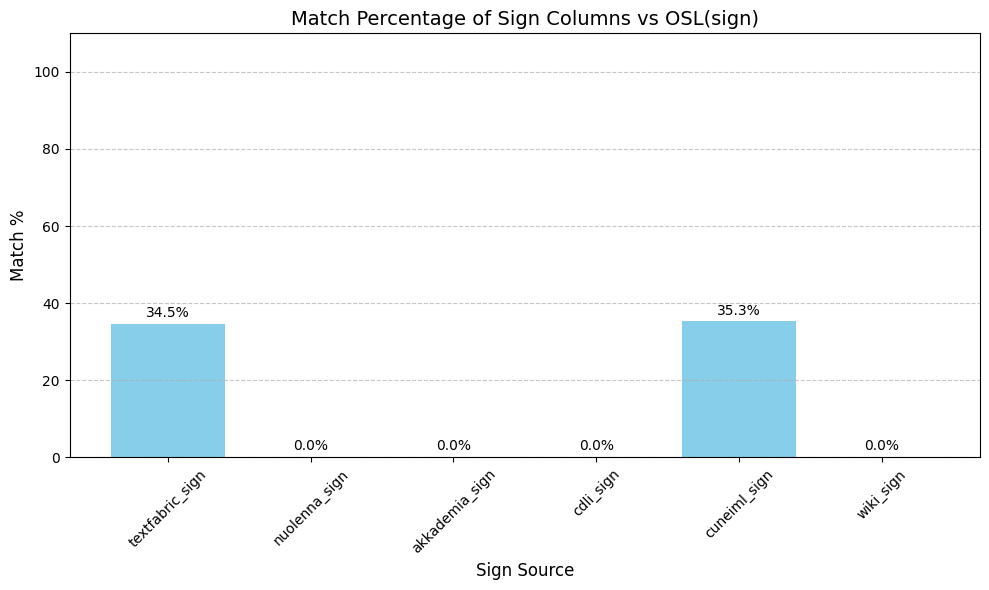

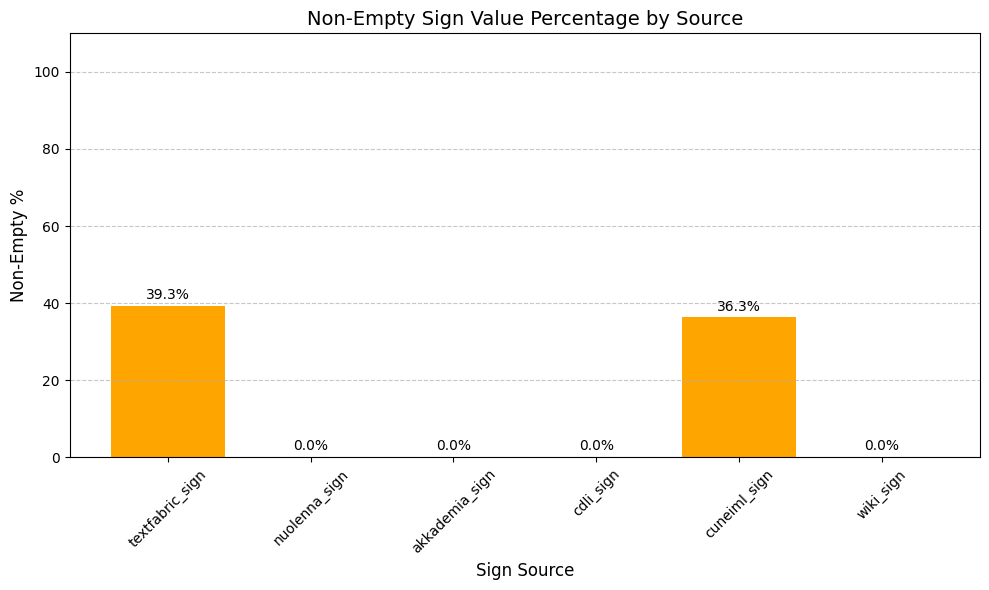

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# --- Normalize Subscripts ---
def normalize_subscripts(value):
    subscript_map = str.maketrans('₀₁₂₃₄₅₆₇₈₉', '0123456789')
    value = re.sub(r'[₀₁₂₃₄₅₆₇₈₉]', lambda x: x.group(0).translate(subscript_map), value)
    value = value.replace('ʾ', "'").replace('?', '')
    return value

# --- Normalize and Clean Osl_df ---
Osl_df = Osl_df.explode('OSL(form)').reset_index(drop=True)
Osl_df = Osl_df[Osl_df['OSL(form)'].notna()]
Osl_df['Normalized_v'] = Osl_df['OSL(form)'].apply(normalize_subscripts)

# --- Merge Info: [(right_df, left_on, right_on)] ---
merge_info = [
    (Cuneiml_df, 'Normalized_v', 'cuneiml_value'),
    (CDLI_df, 'Normalized_v', 'cdli_value'),
    (TextFabric_df, 'Normalized_v', 'textfabric_value'),
    (Akkademia_df, 'Normalized_v', 'akkademia_value'),
    (Nuolenna_df, 'Normalized_v', 'nuolenna_value'),
    (wiki_df, 'Normalized_v', 'wiki_value')
]

# --- Perform Merges Dynamically ---
new_osl = Osl_df.copy()
for right_df, left_on, right_on in merge_info:
    pre_cols = list(new_osl.columns)
    new_osl = pd.merge(new_osl, right_df, left_on=left_on, right_on=right_on, how='left')
    new_cols = [col for col in new_osl.columns if col not in pre_cols]
    print(f"Merged with {right_on}, added columns: {new_cols}")

# --- Compare Unicode Columns to OSL ---
unicode_columns = ["textfabric_sign", "nuolenna_sign", "akkademia_sign", "cdli_sign", "cuneiml_sign", "wiki_sign"]
total_rows = len(new_osl)

for col in unicode_columns:
    match = new_osl['OSL(sign)'] == new_osl[col]
    new_osl[f'{col}_match'] = match
    print(f"{col}: {match.sum()} matches ({match.sum() / total_rows * 100:.2f}%)")

# --- Print sizes of source DataFrames ---
df_names = {
    "TextFabric_df": TextFabric_df,
    "Nuolenna_df": Nuolenna_df,
    "Akkademia_df": Akkademia_df,
    "CDLI_df": CDLI_df,
    "Cuneiml_df": Cuneiml_df,
    "wiki_df": wiki_df
}
for name, df in df_names.items():
    print(f"{name}: {len(df)} rows")

# --- Check non-null counts for sign matches ---
for sign in unicode_columns:
    print(f"{sign}: {new_osl[sign].notna().sum()} non-empty values")

# --- Compute Match Percentages ---
match_counts = {
    col: new_osl[f'{col}_match'].sum() for col in unicode_columns
}
match_percentages = {
    col: (count / total_rows) * 100 for col, count in match_counts.items()
}

# --- Plot: Match Percentage ---
plt.figure(figsize=(10, 6))
bars = plt.bar(match_percentages.keys(), match_percentages.values(), color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Match Percentage of Sign Columns vs OSL(sign)', fontsize=14)
plt.xlabel('Sign Source', fontsize=12)
plt.ylabel('Match %', fontsize=12)
plt.ylim(0, 110)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot: Non-Empty Value Percentage ---
non_empty_counts = {col: new_osl[col].notna().sum() for col in unicode_columns}
non_empty_percentages = {col: (count / total_rows) * 100 for col, count in non_empty_counts.items()}

plt.figure(figsize=(10, 6))
bars = plt.bar(non_empty_percentages.keys(), non_empty_percentages.values(), color='orange')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Non-Empty Sign Value Percentage by Source', fontsize=14)
plt.xlabel('Sign Source', fontsize=12)
plt.ylabel('Non-Empty %', fontsize=12)
plt.ylim(0, 110)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


####2.2.2 Using other sign lists as starting column for matching

In [ ]:
df_names = {
    "TextFabric_df": TextFabric_df,
    "Nuolenna_df": Nuolenna_df,
    "Akkademia_df": Akkademia_df,
    "CDLI_df": CDLI_df,
    "Cuneiml_df": Cuneiml_df,
    "wiki_df": wiki_df,
    "osl_df": Osl_df
}

for name, df in df_names.items():
    df["source_df"] = name

    df.rename(
        columns=lambda col: (
            "value" if "value" in col.lower() else
            "sign" if "sign" in col.lower() else col
        ),
        inplace=True
    )

/tmp/ipython-input-2924358990.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["source_df"] = name
/tmp/ipython-input-2924358990.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(


In [ ]:
wiki_df

,sign,value,oslIDs,source_df
0,𒋶,tibirₓ,o0002400,wiki_df
1,𒇣,šurun₂,o0001834,wiki_df
2,𒇣,šara₃,o0001834,wiki_df
3,𒇣,bara₈,o0001834,wiki_df
4,𒇣,ninmuš,o0001834,wiki_df
...,...,...,...,...
6792,𒊮,lip₃,o0002828,wiki_df
6793,𒊮,pešₓ,o0002828,wiki_df
6794,𒊮,sa₁₉,o0002828,wiki_df
6795,𒊮,šab₂,o0002828,wiki_df


In [ ]:
import pandas as pd

# -----------------------------------------------------------------------------
# 0) Your dataframes dict (already defined elsewhere)
# -----------------------------------------------------------------------------
# df_names = {
#     "TextFabric_df": TextFabric_df,
#     "Nuolenna_df": Nuolenna_df,
#     "Akkademia_df": Akkademia_df,
#     "CDLI_df": CDLI_df,
#     "Cuneiml_df": Cuneiml_df,
#     "wiki_df": wiki_df
# }

# -----------------------------------------------------------------------------
# 1) Tag sources + normalize column names
# -----------------------------------------------------------------------------
for name, df in df_names.items():
    df["source_df"] = name
    # Normalize columns: anything containing 'sign' -> 'sign', 'value' -> 'value'
    df.rename(
        columns=lambda c: ("sign" if "sign" in c.lower() else
                           "value" if "value" in c.lower() else c),
        inplace=True
    )
    # Ensure presence
    if "sign" not in df.columns:  df["sign"] = pd.NA
    if "value" not in df.columns: df["value"] = pd.NA

# -----------------------------------------------------------------------------
# 2) Build wiki_df['oslID'] from oid_* columns; ensure others have empty 'oslID'
# -----------------------------------------------------------------------------
for name, df in df_names.items():
    if name == "wiki_df":
        oid_cols = [c for c in df.columns if str(c).startswith("oid")]
        if oid_cols:
            # join any present OIDs with '|', clean up repeated separators
            df["oslID"] = (
                df[oid_cols]
                .astype(str)
                .replace("nan", "")
                .agg("|".join, axis=1)
                .str.replace(r"\|+", "|", regex=True)
                .str.strip("|")
            )
        else:
            df["oslID"] = ""
    else:
        df["oslID"] = ""  # keep column for consistency

# -----------------------------------------------------------------------------
# 3) Combine + normalized keys + display strings
# -----------------------------------------------------------------------------
combined = pd.concat(df_names.values(), ignore_index=True, sort=False)

def norm(s):
    if pd.isna(s): return pd.NA
    s = str(s).strip()
    return s.lower() if s else pd.NA

combined["sign_norm"]  = combined["sign"].map(norm)
combined["value_norm"] = combined["value"].map(norm)

combined["sign_str"]   = combined["sign"].astype(str)
combined["value_str"]  = combined["value"].astype(str)

# -----------------------------------------------------------------------------
# 4) SIGN crosswalk
#     - For non-wiki sources, show the 'value' in the cell
#     - For wiki_df, show 'oslID' in the cell
#     - Then add a trailing 'oslID' column duplicating wiki's cell for that row
# -----------------------------------------------------------------------------
combined["cell_by_sign"] = combined.apply(
    lambda r: r["oslID"] if r["source_df"] == "wiki_df" else r["value_str"],
    axis=1
)

sign_crosswalk = (
    combined
    .dropna(subset=["sign_norm"])
    .pivot_table(
        index="sign_norm",
        columns="source_df",
        values="cell_by_sign",
        aggfunc=lambda x: "|".join(sorted({s for s in x if s and s not in ("", "nan")})),
        fill_value=""
    )
    .reset_index()  # keep key as a column
)

# Append 'oslID' as the last column (copy of wiki_df column if present)
if "wiki_df" in sign_crosswalk.columns:
    sign_crosswalk["oslID"] = sign_crosswalk["wiki_df"]
else:
    sign_crosswalk["oslID"] = ""

# Make sure 'oslID' is the last column
sc_cols = [c for c in sign_crosswalk.columns if c != "oslID"] + ["oslID"]
sign_crosswalk = sign_crosswalk[sc_cols]

# -----------------------------------------------------------------------------
# 5) VALUE crosswalk
#     - For non-wiki sources, show the 'sign' in the cell
#     - For wiki_df, show 'oslID' in the cell
#     - Then add a trailing 'oslID' column duplicating wiki's cell for that row
# -----------------------------------------------------------------------------
combined["cell_by_value"] = combined.apply(
    lambda r: r["oslID"] if r["source_df"] == "wiki_df" else r["sign_str"],
    axis=1
)

value_crosswalk = (
    combined
    .dropna(subset=["value_norm"])
    .pivot_table(
        index="value_norm",
        columns="source_df",
        values="cell_by_value",
        aggfunc=lambda x: "|".join(sorted({s for s in x if s and s not in ("", "nan")})),
        fill_value=""
    )
    .reset_index()  # keep key as a column
)

# Append 'oslID' as the last column (copy of wiki_df column if present)
if "wiki_df" in value_crosswalk.columns:
    value_crosswalk["oslID"] = value_crosswalk["wiki_df"]
else:
    value_crosswalk["oslID"] = ""

# Ensure 'oslID' is last
vc_cols = [c for c in value_crosswalk.columns if c != "oslID"] + ["oslID"]
value_crosswalk = value_crosswalk[vc_cols]

# -----------------------------------------------------------------------------
# 6) (Optional) Keep only rows present in ≥ 2 sources
# -----------------------------------------------------------------------------
def at_least_two_sources(wide_df):
    # first column is the key (sign_norm/value_norm); last column is 'oslID'
    # count non-empty among the source columns only
    source_cols = wide_df.columns[1:-1]
    non_empty = (wide_df[source_cols].replace("", pd.NA).notna()).sum(axis=1)
    return wide_df.loc[non_empty >= 2]

sign_crosswalk_2plus  = at_least_two_sources(sign_crosswalk)
value_crosswalk_2plus = at_least_two_sources(value_crosswalk)

# -----------------------------------------------------------------------------
# 7) Save (no index; keys are kept as columns)
# -----------------------------------------------------------------------------
# sign_crosswalk.to_csv("sign_crosswalk.csv", index=False)
# value_crosswalk.to_csv("value_crosswalk.csv", index=False)
# sign_crosswalk_2plus.to_csv("sign_crosswalk_2plus.csv", index=False)
# value_crosswalk_2plus.to_csv("value_crosswalk_2plus.csv", index=False)


/tmp/ipython-input-387309549.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["source_df"] = name
/tmp/ipython-input-387309549.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(
/tmp/ipython-input-387309549.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["oslID"] = ""  # keep column for consisten

In [ ]:
sign_crosswalk.to_csv('cross_list_sign_comparison.csv', index=False)
value_crosswalk.to_csv('cross_list_value_comparison.csv', index=False)

In [ ]:
sign_crosswalk

source_df,sign_norm,Akkademia_df,CDLI_df,Cuneiml_df,Nuolenna_df,TextFabric_df,osl_df,wiki_df,oslID
0,mulab₂ 𒀯𒀖,,mulxab₂ 𒀯𒀖,,mulxab₂ 𒀯𒀖,,,,
1,x,n|x,n|x,,,,,,
2,x.𒃲,uszumgalₓ|ušumgalₓ,uszumgalₓ|ušumgalₓ,,,,,,
3,xx,,,,,,None|lubširₓ|šubtum₄|šubtu₄,,
4,xxx,,,,,,None,,
...,...,...,...,...,...,...,...,...,...
5130,󰂑,,,,,,lungaₓ,,
5131,󰂒,,,,,,None|itiₓ,,
5132,󰂓,,,,,,8(geš₂@t)|8(ŋeš₂@t),,
5133,󰂔,,,,,,9(geš₂@t)|9(ŋeš₂@t),,


#### 2.2.3 signlist proposal

In [ ]:
new_osl

,oid_1,oid_2,oid_3,OSL(form),OSL(sign),OSL(value),link_eBL,variant_index,Normalized_v,cuneiml_value,...,nuolenna_sign,wiki_sign,wiki_value,oslIDs,textfabric_sign_match,nuolenna_sign_match,akkademia_sign_match,cdli_sign_match,cuneiml_sign_match,wiki_sign_match
0,o0000087,NaN,NaN,A,𒀀,ʾu₄,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
1,o0000087,NaN,NaN,A,𒀀,a,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
2,o0000087,NaN,NaN,A,𒀀,aia₂,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
3,o0000087,NaN,NaN,A,𒀀,aya₂,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
4,o0000087,NaN,NaN,A,𒀀,barₓ,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(gešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12672,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(ŋešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12673,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(gešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12674,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(ŋešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False


In [ ]:
cross_list_comparison = new_osl.iloc[:, :-6]

In [ ]:
cross_list_comparison

,oid_1,oid_2,oid_3,OSL(form),OSL(sign),OSL(value),link_eBL,variant_index,Normalized_v,cuneiml_value,...,merge_status,textfabric_sign,textfabric_value,akkademia_value,akkademia_sign,nuolenna_value,nuolenna_sign,wiki_sign,wiki_value,oslIDs
0,o0000087,NaN,NaN,A,𒀀,ʾu₄,NaN,0,A,A,...,NaN,𒀀,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,o0000087,NaN,NaN,A,𒀀,a,NaN,0,A,A,...,NaN,𒀀,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,o0000087,NaN,NaN,A,𒀀,aia₂,NaN,0,A,A,...,NaN,𒀀,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,o0000087,NaN,NaN,A,𒀀,aya₂,NaN,0,A,A,...,NaN,𒀀,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,o0000087,NaN,NaN,A,𒀀,barₓ,NaN,0,A,A,...,NaN,𒀀,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(gešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12672,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(ŋešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12673,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(gešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12674,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(ŋešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cross_list_comparison.to_csv('cross_list_comparison.csv', index=False)

In [ ]:
short_osl = new_osl[['OSL(form)','OSL(value)', 'OSL(sign)', 'oid_1', 'Normalized_v', 'cdli_sign', 'cdli_value']]

proposed_signlist = short_osl[
    (short_osl['Normalized_v'] == short_osl['cdli_value']) &
    (short_osl['OSL(sign)'] != short_osl['cdli_sign'])
]

# Remove exact duplicate rows
proposed_signlist = proposed_signlist.drop_duplicates().reset_index(drop=True)

proposed_signlist


,OSL(form),OSL(value),OSL(sign),oid_1,Normalized_v,cdli_sign,cdli_value


In [ ]:
proposed_signlist.to_csv('proposed_signlist.csv', index=False)

#### 2.2.4 Finding values that have different corresponding signs 6.10


In [ ]:
new_osl

,oid_1,oid_2,oid_3,OSL(form),OSL(sign),OSL(value),link_eBL,variant_index,Normalized_v,cuneiml_value,...,nuolenna_sign,wiki_sign,wiki_value,oslIDs,textfabric_sign_match,nuolenna_sign_match,akkademia_sign_match,cdli_sign_match,cuneiml_sign_match,wiki_sign_match
0,o0000087,NaN,NaN,A,𒀀,ʾu₄,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
1,o0000087,NaN,NaN,A,𒀀,a,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
2,o0000087,NaN,NaN,A,𒀀,aia₂,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
3,o0000087,NaN,NaN,A,𒀀,aya₂,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
4,o0000087,NaN,NaN,A,𒀀,barₓ,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(gešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12672,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(ŋešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12673,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(gešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12674,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(ŋešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False


In [ ]:

short_osl_val_sign = new_osl[['OSL(value)', 'OSL(sign)']]


same_val_dif_sign = short_osl_val_sign.merge(
    short_osl_val_sign,
    how='inner',
    left_on='OSL(value)',
    right_on='OSL(value)',
)

filtered_same_val_dif_sign = same_val_dif_sign[
    (same_val_dif_sign['OSL(sign)_x'] != same_val_dif_sign['OSL(sign)_y']) &
    (same_val_dif_sign['OSL(sign)_y'].notna())]
filtered_same_val_dif_sign

,OSL(value),OSL(sign)_x,OSL(sign)_y
5,barₓ,𒀀,𒌋
7,buniŋₓ,𒀀,𒀀𒆹
8,buniŋₓ,𒀀,𒀀𒇉
9,buniŋₓ,𒀀,𒀀𒇒
10,buniŋₓ,𒀀,𒀀X
...,...,...,...
797402,None,󰁇,󰀆
797403,None,󰁇,󰀐
797404,None,󰁇,󰀇
797405,None,󰁇,󰀑


In [ ]:
sign_counts = short_osl_val_sign.groupby('OSL(value)')['OSL(sign)'].nunique()

# Find values that have more than one sign
ambiguous_values = sign_counts[sign_counts > 1]
print(ambiguous_values)

OSL(value)
%akk abnu         2
%akk mahruₓ       2
%akk puzruₓ       2
%akk/n būdu       2
%akk/n muhhuₓ     5
                 ..
šutumₓ            8
šušin             2
šušuₓ             4
šuₓ              10
ṭiₓ               2
Name: OSL(sign), Length: 593, dtype: int64


In [ ]:
unicode_columns = ["cdli_sign", "textfabric_sign", "nuolenna_sign", 'akkademia_sign', 'cuneiml_sign','OSL(sign)', 'wiki_sign']
value_columns = ["cdli_value", "textfabric_value", 'nuolenna_value', 'akkademia_value', 'cuneiml_value','Normalized_v','wiki_value']

ambiguous_values_df = []

for unicode_col, value_col in zip(unicode_columns, value_columns):
    sign_counts = new_osl.groupby(value_col)[unicode_col].nunique()

    # Find values that have more than one sign
    ambiguous_values = sign_counts[sign_counts > 1]
    ambiguous_values_df.append(ambiguous_values)

    print(f'unicode_col is {unicode_col}, value_col is {value_col} with {len(ambiguous_values)} ambiguous_values as follows:  {ambiguous_values}')

unicode_col is cdli_sign, value_col is cdli_value with 0 ambiguous_values as follows:  Series([], Name: cdli_sign, dtype: int64)
unicode_col is textfabric_sign, value_col is textfabric_value with 25 ambiguous_values as follows:  textfabric_value
BARA2     2
BURU5     6
DUR2      2
GE22      2
GURUŠ     2
IDIM      2
IL        2
KEŠ2      2
LIMMU     2
LIMMU2    2
LUM       2
MURGU2    2
NAM2      2
NI2       2
NU11      2
PIRIG     2
SANGA2    2
TIL       2
URI3      2
UTUKI     2
UŠ        2
UŠ2       2
ZI3       2
ZIZ2      2
ZU5       3
Name: textfabric_sign, dtype: int64
unicode_col is nuolenna_sign, value_col is nuolenna_value with 0 ambiguous_values as follows:  Series([], Name: nuolenna_sign, dtype: int64)
unicode_col is akkademia_sign, value_col is akkademia_value with 0 ambiguous_values as follows:  Series([], Name: akkademia_sign, dtype: int64)
unicode_col is cuneiml_sign, value_col is cuneiml_value with 0 ambiguous_values as follows:  Series([], Name: cuneiml_sign, dtype: in

In [ ]:
unicode_columns = ["cdli_sign", "textfabric_sign", "nuolenna_sign", 'akkademia_sign', 'cuneiml_sign','OSL(sign)', 'wiki_sign']
value_columns = ["cdli_value", "textfabric_value", 'nuolenna_value', 'akkademia_value', 'cuneiml_value','Normalized_v','wiki_value']

ambiguous_rows = []

for unicode_col, value_col in zip(unicode_columns, value_columns):
    sign_counts = new_osl.groupby(value_col)[unicode_col].nunique()

    ambiguous_values = sign_counts[sign_counts > 1]

    if not ambiguous_values.empty:
        df = ambiguous_values.reset_index()
        df.columns = ['value', 'num_unique_signs']
        df['value_column'] = value_col
        df['unicode_column'] = unicode_col
        ambiguous_rows.append(df)

# Combine all into one DataFrame
ambiguous_values_df = pd.concat(ambiguous_rows, ignore_index=True)
ambiguous_values_df

,value,num_unique_signs,value_column,unicode_column
0,BARA2,2,textfabric_value,textfabric_sign
1,BURU5,6,textfabric_value,textfabric_sign
2,DUR2,2,textfabric_value,textfabric_sign
3,GE22,2,textfabric_value,textfabric_sign
4,GURUŠ,2,textfabric_value,textfabric_sign
...,...,...,...,...
428,ŠANABI,3,Normalized_v,OSL(sign)
429,ŠID,2,Normalized_v,OSL(sign)
430,ŠIM,2,Normalized_v,OSL(sign)
431,ŠINIG,2,Normalized_v,OSL(sign)


In [ ]:
import pandas as pd

unicode_columns = ["cdli_sign", "textfabric_sign", "nuolenna_sign", 'akkademia_sign', 'cuneiml_sign','OSL(sign)', 'wiki_sign']
value_columns = ["cdli_value", "textfabric_value", 'nuolenna_value', 'akkademia_value', 'cuneiml_value','Normalized_v','wiki_value']

ambiguous_rows = []

for unicode_col, value_col in zip(unicode_columns, value_columns):
    # Group by value and get list of unique signs
    grouped = new_osl.groupby(value_col)[unicode_col].agg(lambda x: list(pd.unique(x.dropna())))

    # Filter values that map to more than one sign
    ambiguous = grouped[grouped.apply(lambda x: len(x) > 1)]

    if not ambiguous.empty:
        df = ambiguous.reset_index()
        df.columns = ['value', 'signs']
        df['num_unique_signs'] = df['signs'].apply(len)
        df['value_column'] = value_col
        df['unicode_column'] = unicode_col
        ambiguous_rows.append(df)

# Combine all into one DataFrame
ambiguous_values_df = pd.concat(ambiguous_rows, ignore_index=True)

# Display the result
print(ambiguous_values_df)


      value                    signs  num_unique_signs      value_column  \
0     BARA2                   [𒁁, 𒁈]                 2  textfabric_value   
1     BURU5  [𒄷𒊺, 𒄷𒊺𒂟, 𒄷𒂟, 𒉆, 𒉆𒂟, 𒉅]                 6  textfabric_value   
2      DUR2                   [𒂉, 𒆪]                 2  textfabric_value   
3      GE22                    [𒀹, ]                 2  textfabric_value   
4     GURUŠ                   [𒄨, 𒆗]                 2  textfabric_value   
..      ...                      ...               ...               ...   
428  ŠANABI                [𒑛, 󰁃, 󰀖]                 3      Normalized_v   
429     ŠID                   [𒋃, 𒔌]                 2      Normalized_v   
430     ŠIM                   [𒋆, 󰁒]                 2      Normalized_v   
431   ŠINIG                  [𒋒, 𒃰𒉀]                 2      Normalized_v   
432  ŠUŠANA                  [𒑚, 𒋙𒊭]                 2      Normalized_v   

      unicode_column  
0    textfabric_sign  
1    textfabric_sign  
2    textfabric_si

In [ ]:
ambiguous_values_df.to_csv('ambiguous_values_df.csv', index=False)

#### 2.2.5 statistic to visualization

In [ ]:
wiki_df

,sign,value,oslIDs,source_df,oslID
0,𒋶,tibirₓ,o0002400,wiki_df,
1,𒇣,šurun₂,o0001834,wiki_df,
2,𒇣,šara₃,o0001834,wiki_df,
3,𒇣,bara₈,o0001834,wiki_df,
4,𒇣,ninmuš,o0001834,wiki_df,
...,...,...,...,...,...
6792,𒊮,lip₃,o0002828,wiki_df,
6793,𒊮,pešₓ,o0002828,wiki_df,
6794,𒊮,sa₁₉,o0002828,wiki_df,
6795,𒊮,šab₂,o0002828,wiki_df,


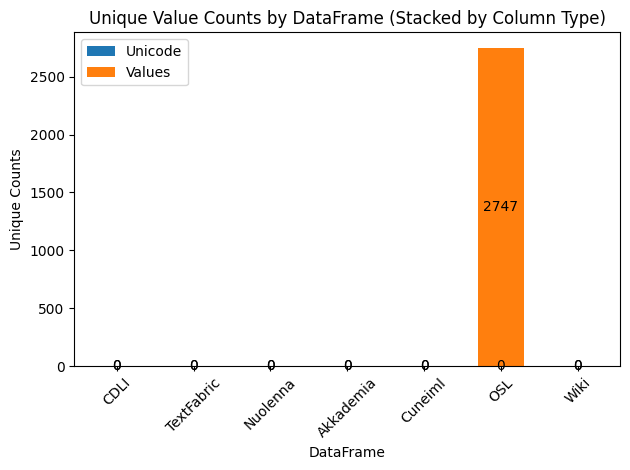

In [ ]:
unicode_columns = ["cdli_sign", "textfabric_sign", "nuolenna_sign", 'akkademia_sign', 'cuneiml_sign','OSL(sign)', 'wiki_sign']
value_columns = ["cdli_value", "textfabric_value", 'nuolenna_value', 'akkademia_value', 'cuneiml_value','Normalized_v','wiki_value']

# List of DataFrames and their names
dataframes = [CDLI_df, TextFabric_df, Nuolenna_df, Akkademia_df, Cuneiml_df, Osl_df, wiki_df]
df_names = ['CDLI', 'TextFabric', 'Nuolenna', 'Akkademia', 'Cuneiml', 'OSL', 'Wiki']


# Initialize a dictionary to hold the unique counts for each type (Unicode and Label)
statistics = {df_name: {'Unicode': 0, 'Values': 0} for df_name in df_names}

# Fix the calculation of unique values
for df, df_name in zip(dataframes, df_names):
    for col in unicode_columns:
        if col in df.columns:
            statistics[df_name]['Unicode'] += df[col].nunique()

    for col in value_columns:
        if col in df.columns:
            # Convert list values to tuples before calling nunique()
            statistics[df_name]['Values'] += df[col].apply(lambda x: tuple(x) if isinstance(x, list) else x).nunique()

# Create a DataFrame for plotting
stats_df = pd.DataFrame(statistics).T  # Transpose to get DataFrame with DataFrame names as index

# Plotting the stacked bar chart
ax = stats_df.plot(kind='bar', stacked=True, width=0.6)

# Add numbers inside each stacked section
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x = p.get_x() + width / 2
    y = p.get_y() + height / 2
    ax.text(x, y, str(int(height)), ha='center', va='center')

# Customize the plot
plt.title('Unique Value Counts by DataFrame (Stacked by Column Type)')
plt.xlabel('DataFrame')
plt.ylabel('Unique Counts')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()



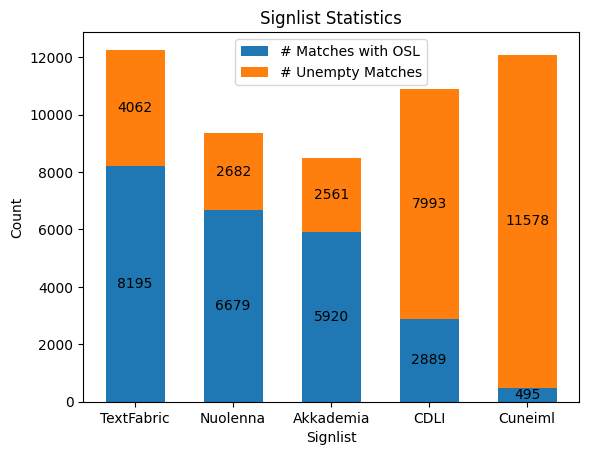

In [ ]:
# Data
sign_lists = ['TextFabric', 'Nuolenna', 'Akkademia','CDLI','Cuneiml']
statistics = {
    "# Matches with OSL": [8195, 6679, 5920, 2889, 495],
    "# Unempty Matches": [4062, 2682, 2561, 7993, 11578],
}

# Create a DataFrame
data = pd.DataFrame(statistics, index=sign_lists)

# Plotting
width = 0.6  # the width of the bars
fig, ax = plt.subplots()

bottom = np.zeros(len(data))

for sign_list in data.columns:
    p = ax.bar(data.index, data[sign_list], width, label=sign_list, bottom=bottom)
    bottom += data[sign_list].values  # Update the bottom for stacked bar

    # Add labels to the bars
    ax.bar_label(p, label_type='center')

ax.set_title('Signlist Statistics')
ax.set_xlabel('Signlist')
ax.set_ylabel('Count')
ax.legend()

plt.show()

In [ ]:
# new_osl.to_csv('boolean_crosssignlist_matches.csv', index=False)
new_osl

,oid_1,oid_2,oid_3,OSL(form),OSL(sign),OSL(value),link_eBL,variant_index,Normalized_v,cuneiml_value,...,nuolenna_sign,wiki_sign,wiki_value,oslIDs,textfabric_sign_match,nuolenna_sign_match,akkademia_sign_match,cdli_sign_match,cuneiml_sign_match,wiki_sign_match
0,o0000087,NaN,NaN,A,𒀀,ʾu₄,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
1,o0000087,NaN,NaN,A,𒀀,a,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
2,o0000087,NaN,NaN,A,𒀀,aia₂,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
3,o0000087,NaN,NaN,A,𒀀,aya₂,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
4,o0000087,NaN,NaN,A,𒀀,barₓ,NaN,0,A,A,...,NaN,NaN,NaN,NaN,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(gešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12672,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(ŋešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12673,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(gešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
12674,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(ŋešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False


In [ ]:
cols_to_check = ['cdli_value', 'textfabric_value', 'nuolenna_value', 'akkademia_value', 'cuneiml_value', 'wiki_value']
new_osl['unique_values'] = new_osl[cols_to_check].apply(lambda row: list(set(row)), axis=1)
for col in cols_to_check:
    new_osl[f'{col}_in_unique'] = new_osl.apply(lambda row: int(pd.notna(row[col]) and row[col] in row['unique_values']),axis=1)

count_cols = [f"{col}_in_unique" for col in cols_to_check]
print(new_osl[count_cols].sum())


cdli_value_in_unique             0
textfabric_value_in_unique    4988
nuolenna_value_in_unique         0
akkademia_value_in_unique        0
cuneiml_value_in_unique       4602
wiki_value_in_unique             0
dtype: int64


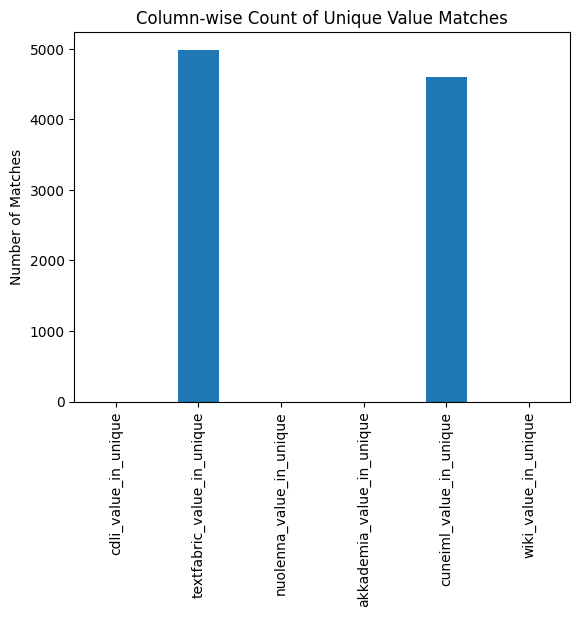

In [ ]:
col_sums = new_osl[count_cols].sum()

col_sums.plot(kind='bar')
plt.title('Column-wise Count of Unique Value Matches')
plt.ylabel('Number of Matches')
plt.show()

In [ ]:
new_osl

,oid_1,oid_2,oid_3,OSL(form),OSL(sign),OSL(value),link_eBL,variant_index,Normalized_v,cuneiml_value,...,cdli_sign_match,cuneiml_sign_match,wiki_sign_match,unique_values,cdli_value_in_unique,textfabric_value_in_unique,nuolenna_value_in_unique,akkademia_value_in_unique,cuneiml_value_in_unique,wiki_value_in_unique
0,o0000087,NaN,NaN,A,𒀀,ʾu₄,NaN,0,A,A,...,False,True,False,"[A, nan]",0,1,0,0,1,0
1,o0000087,NaN,NaN,A,𒀀,a,NaN,0,A,A,...,False,True,False,"[A, nan]",0,1,0,0,1,0
2,o0000087,NaN,NaN,A,𒀀,aia₂,NaN,0,A,A,...,False,True,False,"[A, nan]",0,1,0,0,1,0
3,o0000087,NaN,NaN,A,𒀀,aya₂,NaN,0,A,A,...,False,True,False,"[A, nan]",0,1,0,0,1,0
4,o0000087,NaN,NaN,A,𒀀,barₓ,NaN,0,A,A,...,False,True,False,"[A, nan]",0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(gešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,False,False,False,[nan],0,0,0,0,0,0
12672,o0038260,NaN,NaN,6(|GEŠU@c×KASKAL|),󰀰,6(ŋešʾu@v),NaN,0,6(|GEŠU@c×KASKAL|),NaN,...,False,False,False,[nan],0,0,0,0,0,0
12673,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(gešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,False,False,False,[nan],0,0,0,0,0,0
12674,o0038262,NaN,NaN,7(|GEŠU@c×KASKAL|),󰀱,7(ŋešʾu@v),NaN,0,7(|GEŠU@c×KASKAL|),NaN,...,False,False,False,[nan],0,0,0,0,0,0


In [ ]:
print(type(new_osl['unique_values'].iloc[0]))
print(type(new_osl['cdli_value'].iloc[0]))

<class 'list'>
<class 'float'>


List of unique value, check in each data.

In [ ]:
Cuneiml_df, Akkademia_df, CDLI_df, Nuolenna_df, TextFabric_df, wiki_df

(          value   sign   source_df oslID
 0           kil      𒆸  Cuneiml_df      
 1           kim      𒁶  Cuneiml_df      
 2           kin      𒆥  Cuneiml_df      
 3          dib2      𒆪  Cuneiml_df      
 4           kid      𒆤  Cuneiml_df      
 ...         ...    ...         ...   ...
 7232        tir      𒌁  Cuneiml_df      
 7233  _{lu2}hun    𒇽 𒂠  Cuneiml_df      
 7234        178  𒐖 𒐐 𒐍  Cuneiml_df      
 7235     mašgi;      𒌐  Cuneiml_df      
 7236        526  𒐜 𒐏 𒐋  Cuneiml_df      
 
 [7237 rows x 4 columns],
       value sign     source_df oslID
 0       ʾu₄    𒀀  Akkademia_df      
 1       'u4    𒀀  Akkademia_df      
 2         a    𒀀  Akkademia_df      
 3      aia₂    𒀀  Akkademia_df      
 4      aia2    𒀀  Akkademia_df      
 ...     ...  ...           ...   ...
 14236     /    𒑰  Akkademia_df      
 14237     :    𒑱  Akkademia_df      
 14238    :"    𒑲  Akkademia_df      
 14239    :.    𒑳  Akkademia_df      
 14240    ::      Akkademia_df      
 
 [14241 ro

Combine alphabetical data